In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing, plot_confusion_ascii, write_time
from src.fancy_plots import build_cmap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [ ]:
# let's find the different files we need
config = load_config('config.yaml')
cf_results = config['paths']['counterfactuals']
dt_name = "german_credit"

cf_results

'counterfactuals/'

In [3]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [4]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [5]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.8
Model random_forest Accuracy: 0.75
Model random_forest F1 Score: 0.72
Model random_forest Balanced Accuracy: 0.62
◑•
•◑

Model mlp ROC AUC: 0.72
Model mlp Accuracy: 0.74
Model mlp F1 Score: 0.73
Model mlp Balanced Accuracy: 0.65
◈○
∙◐

Model xgboost ROC AUC: 0.77
Model xgboost Accuracy: 0.74
Model xgboost F1 Score: 0.73
Model xgboost Balanced Accuracy: 0.65
◈○
∙◐

Model lgbm ROC AUC: 0.78
Model lgbm Accuracy: 0.74
Model lgbm F1 Score: 0.73
Model lgbm Balanced Accuracy: 0.65
◑○
•◐



In [6]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [7]:
np.random.randint(0,7), np.random.rand()*7

(3, 3.117944684675949)

In [9]:

                 
import pickle

with open("debug/ranking_new.pkl", "rb") as f:
    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


In [13]:
counterfactuals = {k: [] for k in models.keys()}

# create 4 subplots
all_ranking_list_mean = {k:None for k in models.keys()}
all_ranking_list_std = {k:None for k in models.keys()}
all_ranking_list_min = {k:None for k in models.keys()}
all_ranking_list_max = {k:None for k in models.keys()}
all_probabs = {k:None for k in models.keys()}
all_corrects = {k:None for k in models.keys()}
def get_mean_distance(x,y,policy="l2"):
    if policy == "l2":
        return np.linalg.norm(x-y,axis=1)
    elif policy == "mae":
        return np.abs(x-y).mean(axis=1)
plot = False
if plot:
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs = axs.flatten()
    
start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    print(len(results))
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        i = input()
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    starting2 = time.time()
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file)
    # the value of "cfs" is a np array of dictionaries
    # the keys of the dictionaries are 
    # - instace_idx (the index of the instance in the calibration set)
    # - original_instance (the original class of the instance)
    # - true_class (the true class of the instance)
    
    mean_dists = []
    std_dists = []
    min_dists = []
    max_dists = []
    probabs = []
    corrects = []
    # cfs = {"cfs":np.arange(200)}
    
    for i in tnrange(cfs["cfs"].shape[0]):
        # # since we are now in a local server just create fake data to test the plots
        # mean_dists.append(np.random.rand()*7)
        # std_dists.append(np.random.randint(0,2))
        # min_dists.append(mean_dists[-1]-std_dists[-1])
        # max_dists.append(mean_dists[-1]+std_dists[-1])
        # probabs.append(mean_dists[-1]/7+np.random.rand(2)*0.01)
        # probabs[-1] = probabs[-1]/probabs[-1].sum()
        # continue

        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        original_class = cfs["cfs"][i]["true_class"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        


        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len(true_cf) == 0:
            distancies = np.array([np.inf])
            print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
        else:
            assert (true_cf-true_cf.mean() == 0).all(), "The counterfactuals are not aligned with the target"+str(true_cf)
            #distancies = np.linalg.norm(good_cfs - cfs["cfs"][i]["original_instance"].values,axis=1)
            distancies = get_mean_distance(good_cfs, cfs["cfs"][i]["original_instance"].values)
        mean_dists.append(distancies.mean(axis=0))
        std_dists.append(distancies.std(axis=0))
        min_dists.append(distancies.min(axis=0))
        max_dists.append(distancies.max(axis=0))
        probabs.append(pred_prob)
        corrects.append(correct)

        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
        if plot:
            sns.kdeplot(distancies,cumulative=True,ax=axs[jj],warn_singular=False)

    if plot:
        axs[jj].set_title(k)
    all_ranking_list_mean[k] = mean_dists
    all_ranking_list_std[k] = std_dists
    all_ranking_list_min[k] = min_dists
    all_ranking_list_max[k] = max_dists
    all_probabs[k] = probabs
    all_corrects[k] = corrects
    #print("Time for model",k,"is",write_time(time.time()-starting2))
#print("Time from start",write_time(time.time()-start))
# plot legend for each ax
if plot:
    for ax in axs:
        # put legend under the plot
        #ax.set_xlim([-3,13])
        ax.legend()
        ax.set_xlabel("Distance")
        ax.set_ylabel("Density")
        ax.set_title("Counterfactuals")
    plt.show()
            
                




  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest/german_credit
1
I found 1 files
for model random_forest using file cf_results_dice_kdtree_20241219_171636.npz
checking cf_results_dice_kdtree_20241219_171636.npz


  0%|          | 0/200 [00:00<?, ?it/s]

looking into the folder  counterfactuals/mlp/german_credit
1
I found 1 files
for model mlp using file cf_results_dice_kdtree_20241219_194550.npz
checking cf_results_dice_kdtree_20241219_194550.npz


  0%|          | 0/200 [00:00<?, ?it/s]

looking into the folder  counterfactuals/xgboost/german_credit
2
I found 2 files
0) cf_results_dice_kdtree_20241220_202219.npz
1) cf_results_dice_kdtree_20241219_225952.npz
for model xgboost using file cf_results_dice_kdtree_20241219_225952.npz
checking cf_results_dice_kdtree_20241219_225952.npz


  0%|          | 0/200 [00:00<?, ?it/s]

NOT FOUND COUNTERFACTUALS FOR SAMPLE 0
NOT FOUND COUNTERFACTUALS FOR SAMPLE 2
NOT FOUND COUNTERFACTUALS FOR SAMPLE 3
NOT FOUND COUNTERFACTUALS FOR SAMPLE 9
NOT FOUND COUNTERFACTUALS FOR SAMPLE 14
NOT FOUND COUNTERFACTUALS FOR SAMPLE 17
NOT FOUND COUNTERFACTUALS FOR SAMPLE 18
NOT FOUND COUNTERFACTUALS FOR SAMPLE 22
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 28
NOT FOUND COUNTERFACTUALS FOR SAMPLE 37
NOT FOUND COUNTERFACTUALS FOR SAMPLE 43
NOT FOUND COUNTERFACTUALS FOR SAMPLE 46
NOT FOUND COUNTERFACTUALS FOR SAMPLE 48
NOT FOUND COUNTERFACTUALS FOR SAMPLE 49
NOT FOUND COUNTERFACTUALS FOR SAMPLE 54
NOT FOUND COUNTERFACTUALS FOR SAMPLE 58
NOT FOUND COUNTERFACTUALS FOR SAMPLE 59
NOT FOUND COUNTERFACTUALS FOR SAMPLE 62
NOT FOUND COUNTERFACTUALS FOR SAMPLE 63
NOT FOUND COUNTERFACTUALS FOR SAMPLE 65
NOT FOUND COUNTERFACTUALS FOR SAMPLE 66
NOT FOUND COUNTERFACTUALS FOR SAMPLE 68
NOT FOUND COUNTERFACTUALS FOR SAMPLE 73
NOT FOUND COUNTERFACTUALS FOR SAMPLE 74
NOT 

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
# save the data on the disk under the debug folder 
# all the ranking and the counterfactuals's distances
import pickle
with open("debug/ranking_new.pkl","wb") as f:
    pickle.dump([all_ranking_list_mean,
                 all_ranking_list_std,
                 all_ranking_list_min,
                 all_ranking_list_max,
                 all_probabs,
                 all_corrects],f)
                 


In [16]:
# tranform everything into a numpy array
for k in models.keys():
    all_ranking_list_mean[k] = np.array(all_ranking_list_mean[k])
    all_ranking_list_std[k] = np.array(all_ranking_list_std[k])
    all_ranking_list_min[k] = np.array(all_ranking_list_min[k])
    all_ranking_list_max[k] = np.array(all_ranking_list_max[k])
    all_probabs[k] = np.array(all_probabs[k])
    all_corrects[k] = np.array(all_corrects[k])
    

In [17]:
# now we can see the ranking of the counterfactuals
rankings = [         all_ranking_list_mean,
                     all_ranking_list_std,
                     all_ranking_list_min,
                     all_ranking_list_max]

all_ranking_list_max.keys()

dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])

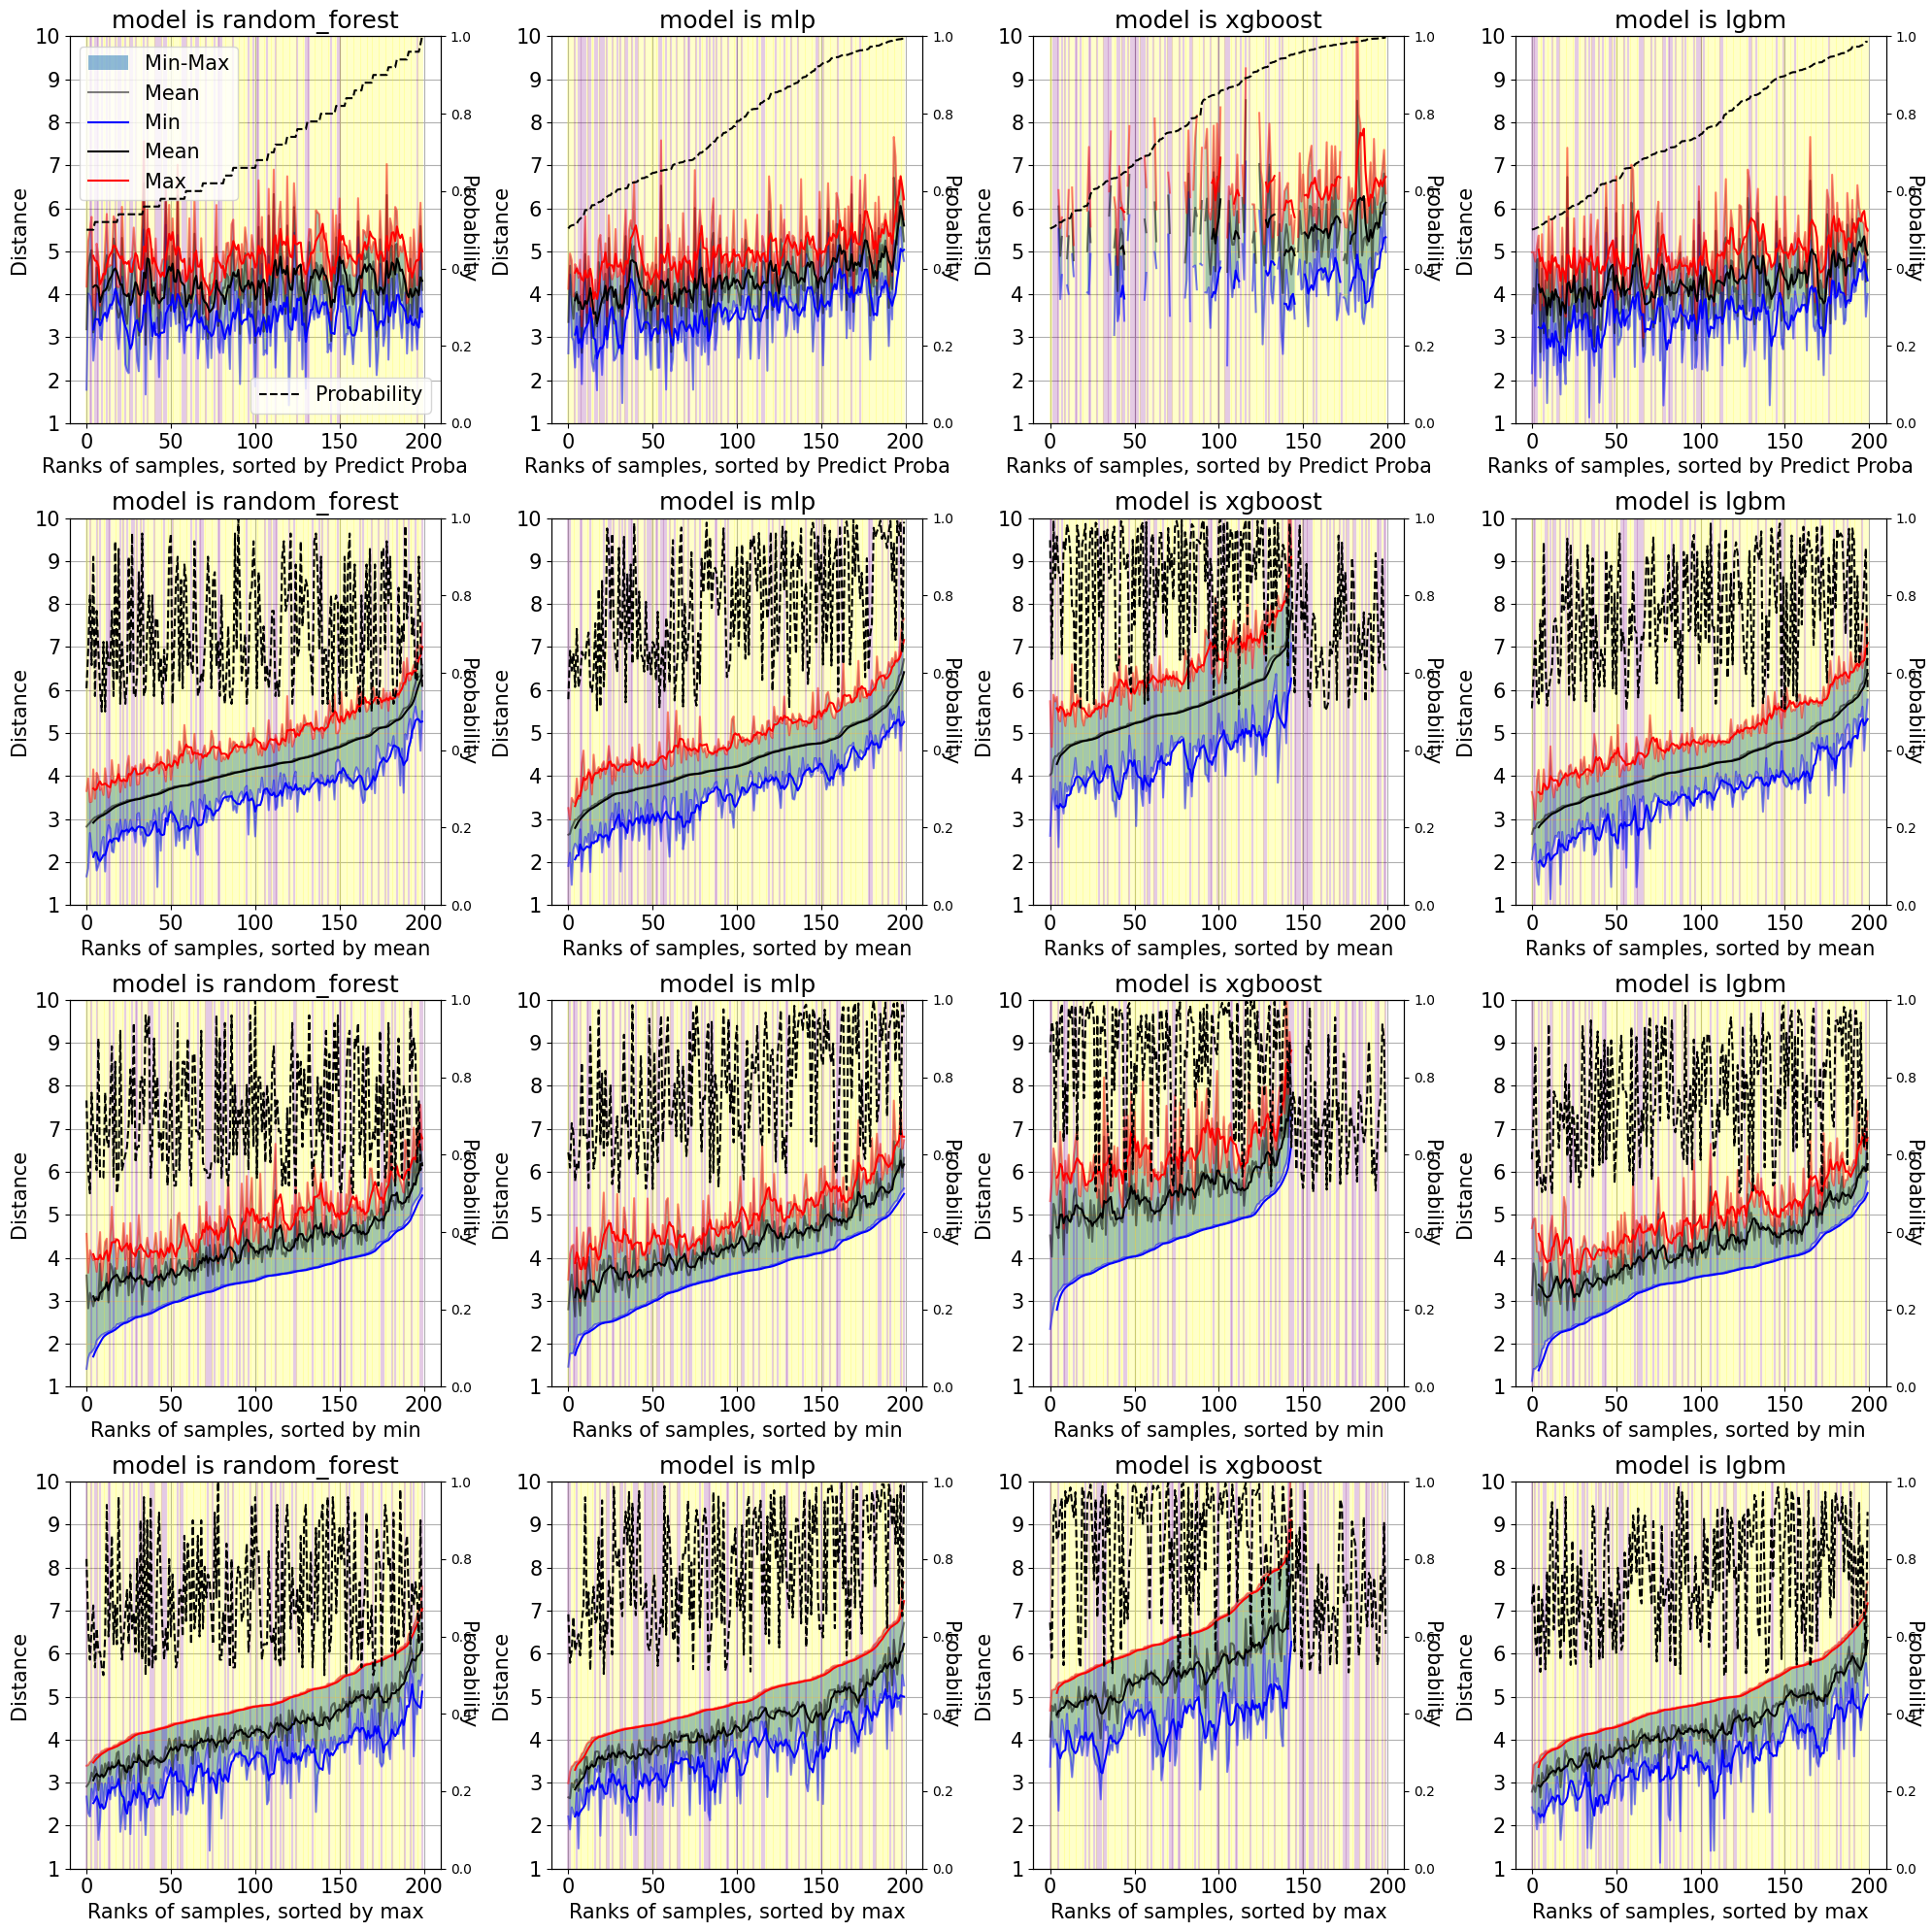

In [23]:
# now the plots!
# create 4 subplots

def create_plot_distances(dictionary,
                          sortby="mean",
                          axe=None,
                          title=None,
                          legend=False,colors = {"min":"blue","max":"red","mean":"black"},
                          ylim = None):
    if axe == None:
        axe = plt.gca()

    min_color = colors["min"]
    max_color = colors["max"]
    mean_color = colors["mean"]

    argsorted = dictionary[sortby].argsort()
    rank_m = dictionary["min"][argsorted]
    rank_M = dictionary["max"][argsorted]
    rank_mean = dictionary["mean"][argsorted]

    if "correct" in dictionary.keys():
        rank_corrects = dictionary["correct"][argsorted]

        # shade the background with vertical lines colored by the corrects
        # if the model is correct the line is green, otherwise it's red
        # the alpha is 0.2, use axvline to plot the vertical lines
        for i in range(len(rank_corrects)):
            if rank_corrects[i]:
                axe.axvline(i,color="yellow",alpha=0.2)
            else:
                axe.axvline(i,color="purple",alpha=0.2)
        

    axe.fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axe.plot(rank_m,alpha=0.5,color=min_color)
    axe.plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axe.plot(rank_M,alpha=0.5,color=max_color)
    #axe.errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    axe.plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(5).mean(),label="Min",color=min_color)
    axe.plot(np.arange(len(rank_mean)),pd.Series(rank_mean).rolling(5).mean(),label="Mean",color=mean_color)
    axe.plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(5).mean(),label="Max",color=max_color)
    axe.set_title(sortby)
    if legend:
        axe.legend(fontsize=15)
    axe.set_xlabel("Ranks of samples, sorted by "+sortby,fontsize=15)
    axe.set_ylabel("Distance",fontsize=15)
    if title != None:
        axe.set_title(title,fontsize=18)
    axe.grid()
    if ylim != None:
        ylims = axe.get_ylim()

        axe.set_ylim(ylim[0],ylim[1])
        
    if "Predict Proba" in dictionary.keys():
        ax2 = axe.twinx()
        rank_prob = dictionary["Predict Proba"][argsorted]
        ax2.plot(np.arange(len(rank_m)),rank_prob,label="Probability",color="black",linestyle="--")
        ax2.set_ylim(0,1)
        ax2.set_ylabel("Probability",fontsize=15,rotation=270)
        if legend:
            # location is lower right
            ax2.legend(fontsize=15,loc="lower right")
    five_perc = int(len(rank_m)*0.05)
    axe.set_xlim([-five_perc,len(rank_m)+five_perc])
    axe.xaxis.set_tick_params(labelsize=15)
    axe.yaxis.set_tick_params(labelsize=15)
    # tight layout
    plt.tight_layout()
    return axe


fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()
# each model goes in a different subplot
# we plot the sorted values of the minimum and the maximum distances,
# then we shade the area between them. On top of that we plot the mean
# at each data point we plot a vertical line with the std value of the distances, centeed at the mean
c=0
for name in ["Predict Proba"]+["mean","min","max"]:
    for k in models.keys():
        create_plot_distances(dictionary={
                                "mean":all_ranking_list_mean[k],
                                "std":all_ranking_list_std[k],
                                "min":all_ranking_list_min[k],
                                "max":all_ranking_list_max[k],
                                "Predict Proba":np.array(all_probabs[k]).max(axis=1),
                                "correct":np.array(all_corrects[k])
                                },
                        sortby=name,
                        axe=axs[c],
                        title="model is "+k,
                        legend=(True if c==0 else False ),#%4== 0 else False),
                        ylim = (1,10))
        c+=1
plt.tight_layout()
date = time.strftime("%Y-%m-%d_%H")
plt.savefig(os.path.join("plots",
                         "counterfactuals_"+"dice_"+date+".pdf")
        )
plt.show()

## There is a correlation?
Let's see if there is a correlation between the L2 distances (min, max, mean) and theprobability output of the model.


In [25]:
all_ranking_list_min.keys(),models.keys()


(dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm']),
 dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm']))

In [26]:
from src.fancy_plots import build_cmap, gold_map
from seaborn import cm

Correlation between random_forest's output prob and the distances:
Min 0.089
Max 0.138
Mean 0.104

Correlation between mlp's output prob and the distances:
Min 0.446
Max 0.403
Mean 0.456

Correlation between xgboost's output prob and the distances:
Min -0.015
Max 0.069
Mean 0.048

Correlation between lgbm's output prob and the distances:
Min 0.302
Max 0.265
Mean 0.297



Text(95.72222222222221, 0.5, 'Distances')

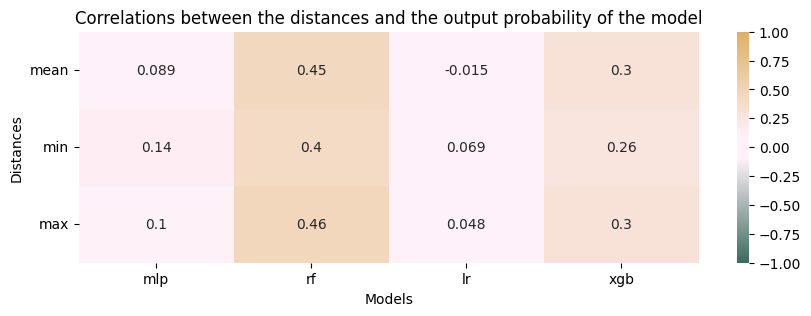

In [28]:
# check the correlation between the distances and the predict probailities of the model
# we can use the predict_proba of the model to get the probability of the class
correlations = {}
for k in models.keys():
    
    correlations[k] = {}
    print(f"Correlation between {k}'s output prob and the distances:")
    notna_min =  np.isfinite(all_ranking_list_min[k]) # tilde is the not operator: ~
    notna_max =  np.isfinite(all_ranking_list_max[k])
    notna_mean = np.isfinite(all_ranking_list_mean[k])
    correlations[k]["min"] = np.corrcoef(all_ranking_list_min[k][notna_min]  ,  
                                        np.array(all_probabs[k])[notna_min].max(axis=1))[0,1]
    correlations[k]["max"] = np.corrcoef(all_ranking_list_max[k][notna_max]  ,  
                                        np.array(all_probabs[k])[notna_max].max(axis=1))[0,1]
    correlations[k]["mean"]=np.corrcoef(all_ranking_list_mean[k][notna_mean],  
                                        np.array(all_probabs[k])[notna_mean].max(axis=1))[0,1]
    print("Min",np.round(correlations[k]["min"],3))
    print("Max",np.round(correlations[k]["max"],3))
    print("Mean",np.round(correlations[k]["mean"],3))
    print()


correlations = pd.DataFrame(correlations).values

# def plot_correlations()
#correlations = np.random.rand(3,4)*2-1
#correlations.shape
# plot the correlations as colored ig squares with the value inside using sns
fig, ax = plt.subplots(1,1,figsize=(10,3))
gold_map_r  = build_cmap(0.1,'#3c6b5e', '#fff1f9','#deb062')

sns.heatmap(correlations,annot=True,ax=ax,vmin=-1,vmax=1,cmap=gold_map_r)#build_cmap(0.7,c1="blue",c3="red"))
ax.set_yticklabels(["mean","min","max"],rotation=0)
ax.set_xticklabels(["mlp","rf","lr","xgb"])
ax.set_title("Correlations between the distances and the output probability of the model")
plt.xlabel("Models")
plt.ylabel("Distances")




In [29]:
np.array(corrects).reshape(-1).shape, np.array(all_probabs[k]).max(axis=1).shape

((200,), (200,))

# The Selective Classifiers framework

Selective classification allows classifiers to abstain from predicting, avoiding making mistakes over difficult instances. In this notebook we show how to use the selective classification framework to train selective classifiers and evaluate them. We use the Adult dataset, which is a binary classification task. We use the LightGBM classifier as base model for the selective classifiers. We train the selective classifiers using the training set, calibrate them using the calibration set, and evaluate them using the test set. We use the accuracy as metric for the evaluation of the selective classifiers. We also show how to use the AUC as metric for the evaluation of the selective classifiers.

More formally we have:
- $X$ are the features
- $Y$ are the target variables
- $f: X \rightarrow Y$ is the base classifier
- $g: X \rightarrow \{0,1\}$ is the selection function

The selective classifier is then the pair $(f,g)$, i.e.

\begin{equation}
(f,g)(x) = \begin{cases}
f(x) \quad \text{if } g(x) = 1 \\
\text{abstain} \quad \text{if } g(x) = 0
\end{cases}
\end{equation}

To build a selective classifier, one has to specify a target coverage $c \in [0,1]$, which is the percentage of instances that the selective classifier is allowed to abstain from predicting. The selective classifier is then calibrated to predict on $c$ fraction of the instances. Depending on the methodology, one might need a calibration set to calibrate the selective classifier to achieve the target coverage. Ideally, the more we abstain the more we reduce the number of mistakes, hence performance should improve.

In [111]:
from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
import matplotlib.pyplot as plt
from OLD_src.MyLoreSA.metrics import nonrejected_accuracy, classification_quality, rejection_quality, rejection_classification_report

In [112]:
splits['X_calibration']

,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,other_debtors,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,2.0,1.252574,3.0,4.0,0.425949,1.0,0.0,0.918477,3.0,2.0,-0.765977,1.0,-0.399832,1.0,1.0,-0.704926,1.0,-0.428290,0.0,1.0
1,1.0,-1.236478,3.0,2.0,4.120313,1.0,0.0,-1.764514,3.0,2.0,1.046987,3.0,2.854409,0.0,1.0,-0.704926,0.0,-0.428290,1.0,1.0
2,1.0,0.256953,3.0,1.0,1.168508,1.0,2.0,-0.870183,2.0,2.0,-0.765977,1.0,-1.279356,2.0,1.0,-0.704926,3.0,-0.428290,0.0,1.0
3,0.0,0.505858,3.0,1.0,-0.263443,1.0,1.0,0.918477,0.0,2.0,-1.672459,0.0,-0.311879,1.0,1.0,-0.704926,1.0,2.334869,1.0,1.0
4,2.0,-0.738668,3.0,4.0,-0.699763,1.0,2.0,0.024147,2.0,2.0,1.046987,2.0,-1.103451,1.0,2.0,-0.704926,1.0,-0.428290,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,3.0,-1.236478,2.0,1.0,-0.541681,2.0,2.0,-1.764514,3.0,2.0,-0.765977,2.0,-0.135974,1.0,1.0,1.027079,3.0,-0.428290,0.0,1.0
196,0.0,1.252574,4.0,4.0,0.188827,1.0,2.0,0.918477,0.0,2.0,-1.672459,1.0,0.567645,1.0,1.0,-0.704926,1.0,-0.428290,1.0,1.0
197,0.0,-0.738668,2.0,4.0,-0.952126,1.0,2.0,0.918477,2.0,0.0,1.046987,2.0,-1.367309,1.0,2.0,1.027079,1.0,-0.428290,0.0,1.0
198,3.0,1.501479,3.0,3.0,1.884484,2.0,0.0,0.918477,3.0,2.0,-0.765977,1.0,0.831502,1.0,1.0,-0.704926,0.0,-0.428290,1.0,1.0


In [115]:
calibration_data  = splits['X_calibration'].copy()
calibration_data["target"] = splits['y_calibration']

#### Auxiliary functions
We start by defining some auxiliary functions that we will use later on.

In [116]:
def get_index_rejected(qband_list, i):
    return [j for j, qband in enumerate(qband_list) if qband >= i]
# create: rejected_list is a 0/1 list with 1 at rejected indices
# qband is a list with levels of acceptance: for j in range(len(target_coverage)), qband>=j is rejected
# qband >= i means setting to 0 (accept) all samples above i


def get_rejected_list(qband, i):
    return [1 if qband >= i else 0 for qband in qband]

## Selective Classification:
Improves reliability by allowing the model to abstain from making predictions for uncertain samples (rejected samples).

Plug-In Rule: A method for calibrating models for selective classification based on specified coverage levels.

## Performance Metrics:

   - Non-Rejected Accuracy (AN): Accuracy of predictions for samples not rejected.
   - Classification Quality (CQ): A holistic measure of model performance (possibly combining coverage and accuracy).
   - Rejection Quality (RQ): A measure of how well rejected predictions match the expected quality.

In [117]:
plug_in_rulers = {}
rejected_by_coverage = {}
classification_quality_dict = {}
rejection_quality = {}
target_coverages_n = 100
n = len(splits['X_test'])

for k in models.keys():
    rejected_by_coverage[k] = {}
    classification_quality[k] = {}
    rejection_quality[k] = {}
    plug_in_rulers[k] = {}

TypeError: 'function' object does not support item assignment

Model random_forest


TypeError: 'dict' object is not callable

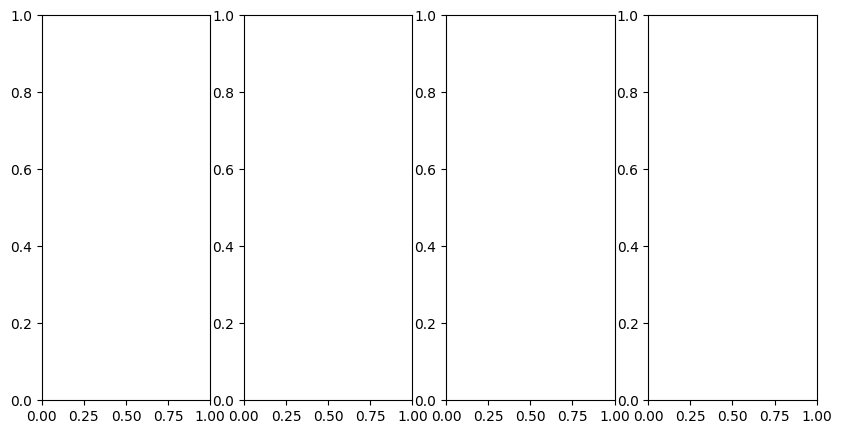

In [119]:
#iterate over the models
plot = True
if plot:
    fig, ax = plt.subplots(1,len(models.keys()),figsize=(10,5))
    ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    print("Model",k)
    ## SELECTIVE CLASSIFIERS
    # create the plug in rule
    plug_in_rule = PlugInRule(model=models[k])
    #scr = SCRoss(model=models[k])

    #calibrate selective classifiers for target coverages
    rej_rate_list = np.linspace(0,1.0,num=target_coverages_n)
    target_coverages = [1-n for n in rej_rate_list]

    #target_coverages = [.99, .75, .50] # here we define the target coverages for the selective classifiers
    plug_in_rule.calibrate(splits["X_calibration"], target_coverages=target_coverages)
    # scr.calibrate(target_coverages=target_coverages)

    # here we create an array containing levels for acceptance depending on how the selective classifiers are calibrated
    # since we used 100 target coverages, we have 101 levels of acceptance, i.e., 0, 1, 2, 3, ..., 100
    selected_plg = plug_in_rule.qband(splits["X_test"])
    #selected_scr = scr.qband(splits["X_test"])


    
    for i in range(10):
        qband = i
        cov = 1 - target_coverages[i] # save as rejection rate, not coverage
        #rejected list is a 0/1 list with 1 at rejected indices
        rejected_list_plg = get_rejected_list(selected_plg, i)
        
        (correct_nonrejected_plg,
        correct_rejected_plg,
        miscl_nonrejected_plg,
        miscl_rejected_plg,
        df_plg) = rejection_classification_report(splits['y_test'].values.reshape(-1),
                                        plug_in_rule.predict(splits['X_test']), 
                                        rejected_list_plg)

    
    # n = len(df_test['TARGET'])
        # get performance metrics
        AN_plg = nonrejected_accuracy(correct_nonrejected_plg, miscl_nonrejected_plg)
        CQ = classification_quality(correct_nonrejected_plg, miscl_rejected_plg, n)
        RQ = rejection_quality(correct_rejected_plg, correct_nonrejected_plg, miscl_rejected_plg, miscl_nonrejected_plg)
        
        
        rejected_by_coverage[k][cov] = AN_plg
        classification_quality_dict[k][cov] = CQ
        rejection_quality_dict[k][cov] = RQ
    if plot:
        ax[jj].plot(rejected_by_coverage_plg.keys(), rejected_by_coverage_plg.values(), label='PlugInRule'+k)
        ax[jj].legend()
        ax[jj].set_title(k)
        ax[jj].set_xlabel('Rejection rate')
        ax[jj].set_ylabel('Non-rejected accuracy')
    


In [95]:

for i in range(10):
    qband = i
    cov = 1 - target_coverages[i] # save as rejection rate, not coverage
    #rejected list is a 0/1 list with 1 at rejected indices
    rejected_list_plg = get_rejected_list(selected_plg, i)
    
    (correct_nonrejected_plg,
     correct_rejected_plg,
     miscl_nonrejected_plg,
     miscl_rejected_plg,
     df_plg) = rejection_classification_report(splits['y_test'].values.reshape(-1),
                                    plug_in_rule.predict(splits['X_test']), 
                                    rejected_list_plg)

   
   # n = len(df_test['TARGET'])
    # get performance metrics
    AN_plg = nonrejected_accuracy(correct_nonrejected_plg, miscl_nonrejected_plg)
    CQ = classification_quality(correct_nonrejected_plg, miscl_rejected_plg, n)
    RQ = rejection_quality(correct_rejected_plg, correct_nonrejected_plg, miscl_rejected_plg, miscl_nonrejected_plg)
    
    
    rejected_by_coverage_plg[cov] = AN_plg
    classification_quality_plg[cov] = CQ
    rejection_quality_plg[cov] = RQ



Text(0, 0.5, 'Non-rejected accuracy')

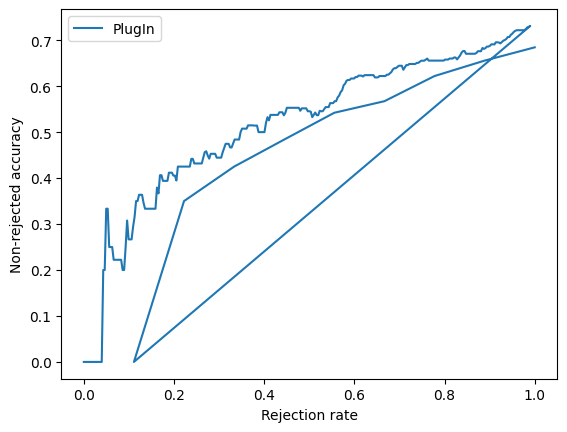

In [96]:
plt.plot(rejected_by_coverage_plg.keys(), rejected_by_coverage_plg.values(), label='PlugIn')
#plt.plot(rejected_by_coverage_plgauc.keys(), rejected_by_coverage_plgauc.values(), label = 'PlugInAuc')
#plt.plot(rejected_by_coverage_scr.keys(), rejected_by_coverage_scr.values(), label='SCRoss')
plt.legend()
plt.xlabel('Rejection rate')
plt.ylabel('Non-rejected accuracy')

In [105]:
# check that the selective classifiers are able to identify instances where they make less mistakes
print("PLG - full coverage: ", accuracy_score(splits['y_test'].values.reshape(-1)[selected_plg>=0], plug_in_rule.predict(splits['X_test'][selected_plg>=0])))
print("PLG - predicting on 99% of cases: ", accuracy_score(splits['y_test'].values.reshape(-1)[selected_plg>=1], plug_in_rule.predict(splits['X_test'][selected_plg>=1])))
print("PLG - predicting on 75% of cases: ", accuracy_score(splits['y_test'].values.reshape(-1)[selected_plg>=2], plug_in_rule.predict(splits['X_test'][selected_plg>=2])))
print("PLG - predicting on 50% of cases: ", accuracy_score(splits['y_test'].values.reshape(-1)[selected_plg>=3], plug_in_rule.predict(splits['X_test'][selected_plg>=3])))
print("PLG - predicting on 25% of cases: ", accuracy_score(splits['y_test'].values.reshape(-1)[selected_plg>=4], plug_in_rule.predict(splits['X_test'][selected_plg>=4])))


PLG - full coverage:  0.752
PLG - predicting on 99% of cases:  0.751004016064257
PLG - predicting on 75% of cases:  0.7652173913043478
PLG - predicting on 50% of cases:  0.780952380952381
PLG - predicting on 25% of cases:  0.8031914893617021


In [ ]:
from utils import evaluate_coverage_accuracy


splits = {
    'X_test': X_test,  # Feature set
    'y_test': y_test   # True labels
}
percentages = [99, 75, 50, 25, 1]  # Coverage percentages to evaluate

plug_in_rule = PlugInRule(models[k])
# Call the function
results = evaluate_coverage_accuracy(plug_in_rule, splits, percentages)